# Probe registration placement analysis

This notebook inspects a registered mmcnirs `probe.npz` independently of Jacobian generation and simulation. Its core diagnostics use **only the probe archive**. If a sibling `mesh.npz` is available, an optional section adds surface-distance checks.

Change `PROBE_PATH` below and run all cells. No input files are modified.

## Diagnostic questions

The notebook is organized around placement failures that should be caught immediately after registration:

- Are all positions, directions, element IDs, and pairings structurally valid?
- Are direction vectors finite and unit length?
- Are any sources or detectors coincident, nearly coincident, isolated, or unused?
- Do stored short/long channel IDs form a complete, disjoint partition?
- Does the 3D placement look mirrored, shifted, compressed, or dominated by crossing/outlier channels?
- Are channel separations and optode participation plausible for the intended montage?
- When a mesh is available, are registered optodes inside the mesh and are detector centers deeper than the capture radius expected by the forward model?

Fatal findings invalidate the registered probe. Review findings are not necessarily wrong, but should be understood before generating Jacobians.

In [41]:
from html import escape
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display
from matplotlib.lines import Line2D

plt.rcParams.update(
    {
        "figure.dpi": 115,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.22,
    }
)

def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError("Could not find a project root containing pyproject.toml")

PROJECT_ROOT = find_project_root(Path.cwd())

# Main input: this is the only required file.
PROBE_PATH = PROJECT_ROOT / "workflow_example/e2e-files" / "mmcnirs_outputs" / "probe.npz"

# Optional input. Set to None to run strictly probe-only diagnostics.
MESH_PATH = PROBE_PATH.with_name("mesh.npz")

# Quality thresholds. Adapt these to the registration/forward-model contract.
POSITION_COLLISION_ATOL_MM = 1e-6
MIN_OPTODE_SPACING_REVIEW_MM = 1.0
DIRECTION_NORM_ATOL = 1e-6
MESH_SURFACE_ATOL_MM = 1e-3

# Must match the detector radius used by the forward model; set to None to disable.
EXPECTED_DETECTOR_CAPTURE_RADIUS_MM = 1.0

# Plot controls.
DIRECTION_ARROW_LENGTH_MM = 3.0
LABEL_2D_OPTODES = True

print(f"Probe: {PROBE_PATH}")
print(f"Mesh:  {MESH_PATH if MESH_PATH is not None and MESH_PATH.exists() else 'not used'}")

Probe: /Users/nielsbracher/Projects/mmc-nirs/workflow_example/e2e-files/mmcnirs_outputs/probe.npz
Mesh:  /Users/nielsbracher/Projects/mmc-nirs/workflow_example/e2e-files/mmcnirs_outputs/mesh.npz


In [42]:
def load_npz(path: Path) -> dict[str, np.ndarray]:
    if not path.is_file():
        raise FileNotFoundError(path)
    with np.load(path, allow_pickle=False) as archive:
        return {key: archive[key] for key in archive.files}

def human_bytes(size: int) -> str:
    value = float(size)
    for unit in ("B", "KiB", "MiB", "GiB"):
        if value < 1024 or unit == "GiB":
            return f"{value:.1f} {unit}"
        value /= 1024
    raise AssertionError("unreachable")

probe = load_npz(PROBE_PATH)
memory_bytes = sum(array.nbytes for array in probe.values())

print(f"Loaded {len(probe)} arrays ({human_bytes(memory_bytes)} in memory)")
print(f"{'key':<28} {'shape':<16} {'dtype':<12} {'size'}")
for key, array in probe.items():
    print(f"{key:<28} {str(array.shape):<16} {str(array.dtype):<12} {human_bytes(array.nbytes)}")

Loaded 9 arrays (3.7 KiB in memory)
key                          shape            dtype        size
sourcepos                    (15, 3)          float64      360.0 B
detpos                       (31, 3)          float64      744.0 B
sourcedir                    (15, 3)          float64      360.0 B
detnorms                     (31, 3)          float64      744.0 B
source_elements              (15,)            int64        120.0 B
detector_elements            (31,)            int64        248.0 B
channel_pairings             (51, 2)          int64        816.0 B
short_separation_indices     (15,)            int64        120.0 B
long_separation_indices      (36,)            int64        288.0 B


In [43]:
REQUIRED_PROBE_KEYS = {
    "sourcepos",
    "detpos",
    "sourcedir",
    "detnorms",
    "source_elements",
    "detector_elements",
    "channel_pairings",
    "short_separation_indices",
    "long_separation_indices",
}

quality_findings: list[dict[str, object]] = []

def add_finding(
    check: str,
    bad_count: int,
    detail: str,
    failure_level: str = "FATAL",
) -> None:
    quality_findings.append(
        {
            "status": "PASS" if bad_count == 0 else failure_level,
            "check": check,
            "count": int(bad_count),
            "detail": detail,
        }
    )

def add_status(status: str, check: str, detail: str) -> None:
    quality_findings.append(
        {"status": status, "check": check, "count": 0, "detail": detail}
    )

missing = sorted(REQUIRED_PROBE_KEYS - probe.keys())
if missing:
    add_finding("Required probe fields", len(missing), f"Missing: {', '.join(missing)}")
    raise KeyError(f"Missing required probe arrays: {missing}")
add_finding("Required probe fields", 0, "All expected arrays are present")

source_positions = np.asarray(probe["sourcepos"], dtype=float)
detector_positions = np.asarray(probe["detpos"], dtype=float)
source_directions = np.asarray(probe["sourcedir"], dtype=float)
detector_directions = np.asarray(probe["detnorms"], dtype=float)

if source_positions.ndim != 2 or source_positions.shape[1] != 3:
    raise ValueError(f"sourcepos must have shape (n_sources, 3), got {source_positions.shape}")
if detector_positions.ndim != 2 or detector_positions.shape[1] != 3:
    raise ValueError(f"detpos must have shape (n_detectors, 3), got {detector_positions.shape}")

source_count = len(source_positions)
detector_count = len(detector_positions)
expected_shapes = {
    "sourcedir": (source_count, 3),
    "detnorms": (detector_count, 3),
    "source_elements": (source_count,),
    "detector_elements": (detector_count,),
}
shape_errors = [
    f"{key}: expected {expected}, got {np.asarray(probe[key]).shape}"
    for key, expected in expected_shapes.items()
    if np.asarray(probe[key]).shape != expected
]
add_finding(
    "Probe array dimensions",
    len(shape_errors),
    "Core arrays match source and detector counts"
    if not shape_errors
    else "; ".join(shape_errors),
)
if shape_errors:
    raise ValueError("Probe schema errors:\n" + "\n".join(shape_errors))

all_positions = np.vstack((source_positions, detector_positions))
all_directions = np.vstack((source_directions, detector_directions))
optode_labels = [f"S{i + 1}" for i in range(source_count)] + [
    f"D{i + 1}" for i in range(detector_count)
]

invalid_position_rows = ~np.isfinite(all_positions).all(axis=1)
invalid_direction_rows = ~np.isfinite(all_directions).all(axis=1)
direction_norms = np.linalg.norm(all_directions, axis=1)
bad_direction_norms = (
    invalid_direction_rows
    | ~np.isfinite(direction_norms)
    | (np.abs(direction_norms - 1.0) > DIRECTION_NORM_ATOL)
)
add_finding(
    "Finite optode coordinates",
    np.count_nonzero(invalid_position_rows),
    f"Checked {len(all_positions)} optodes",
)
add_finding(
    "Finite unit direction vectors",
    np.count_nonzero(bad_direction_norms),
    f"Expected norm 1 ± {DIRECTION_NORM_ATOL:g}",
)

source_elements_raw = np.asarray(probe["source_elements"])
detector_elements_raw = np.asarray(probe["detector_elements"])
element_values = np.concatenate((source_elements_raw, detector_elements_raw))
elements_are_integral = (
    np.issubdtype(element_values.dtype, np.integer)
    or (
        np.issubdtype(element_values.dtype, np.number)
        and np.all(np.isfinite(element_values))
        and np.all(element_values == np.floor(element_values))
    )
)
if not elements_are_integral:
    raise ValueError("source_elements and detector_elements must contain integers")
source_elements = source_elements_raw.astype(np.intp, copy=False)
detector_elements = detector_elements_raw.astype(np.intp, copy=False)
negative_element_count = np.count_nonzero(
    np.concatenate((source_elements, detector_elements)) < 0
)
add_finding(
    "Non-negative registered element IDs",
    negative_element_count,
    "Upper bounds are checked when mesh.npz is available",
)

pairings = np.asarray(probe["channel_pairings"])
pairings_are_integral = (
    pairings.ndim == 2
    and pairings.shape[1] == 2
    and (
        np.issubdtype(pairings.dtype, np.integer)
        or (
            np.issubdtype(pairings.dtype, np.number)
            and np.all(np.isfinite(pairings))
            and np.all(pairings == np.floor(pairings))
        )
    )
)
if not pairings_are_integral:
    raise ValueError("channel_pairings must have shape (n_channels, 2) with integer values")
pairings = pairings.astype(np.intp, copy=False)
pairing_out_of_range = (
    (pairings[:, 0] < 0)
    | (pairings[:, 0] >= source_count)
    | (pairings[:, 1] < 0)
    | (pairings[:, 1] >= detector_count)
)
add_finding(
    "Pairing index range",
    np.count_nonzero(pairing_out_of_range),
    "Pairings use zero-based source and detector indices",
)
if np.any(pairing_out_of_range):
    raise ValueError("channel_pairings contains out-of-range source or detector indices")
duplicate_pair_count = len(pairings) - len(np.unique(pairings, axis=0))
add_finding("Unique channel pairings", duplicate_pair_count, f"{len(pairings)} channels")

short_indices = np.asarray(probe["short_separation_indices"])
long_indices = np.asarray(probe["long_separation_indices"])
metadata_integral = (
    np.issubdtype(short_indices.dtype, np.integer)
    and np.issubdtype(long_indices.dtype, np.integer)
)
if not metadata_integral:
    raise ValueError("short/long separation indices must be integer arrays")
short_indices = short_indices.astype(np.intp, copy=False).reshape(-1)
long_indices = long_indices.astype(np.intp, copy=False).reshape(-1)
classification_invalid = (
    np.any(short_indices < 0)
    or np.any(short_indices >= len(pairings))
    or np.any(long_indices < 0)
    or np.any(long_indices >= len(pairings))
    or len(np.intersect1d(short_indices, long_indices)) > 0
    or len(np.union1d(short_indices, long_indices)) != len(pairings)
)
add_finding(
    "Stored short/long partition",
    int(classification_invalid),
    "Stored channel IDs must be disjoint and cover every pairing",
)
if classification_invalid:
    raise ValueError("Invalid short/long channel partition")

channel_is_short = np.zeros(len(pairings), dtype=bool)
channel_is_short[short_indices] = True
channel_is_long = ~channel_is_short

source_indices = pairings[:, 0]
detector_indices = pairings[:, 1]
channel_distances = np.linalg.norm(
    source_positions[source_indices] - detector_positions[detector_indices],
    axis=1,
)
bad_channel_distance = ~np.isfinite(channel_distances) | (channel_distances <= 0)
add_finding(
    "Finite positive channel separations",
    np.count_nonzero(bad_channel_distance),
    "Coincident source-detector channels are invalid",
)

pairwise_distances = np.linalg.norm(
    all_positions[:, None, :] - all_positions[None, :, :],
    axis=2,
)
np.fill_diagonal(pairwise_distances, np.inf)
nearest_neighbor_index = np.argmin(pairwise_distances, axis=1)
nearest_neighbor_distance = pairwise_distances[
    np.arange(len(all_positions)), nearest_neighbor_index
]
collision_pairs = np.argwhere(
    np.triu(pairwise_distances <= POSITION_COLLISION_ATOL_MM, k=1)
)
add_finding(
    "No coincident optodes",
    len(collision_pairs),
    f"Collision tolerance: {POSITION_COLLISION_ATOL_MM:g} mm",
)
close_optode_count = np.count_nonzero(
    nearest_neighbor_distance < MIN_OPTODE_SPACING_REVIEW_MM
)
add_finding(
    "Nearest-optode spacing",
    close_optode_count,
    f"Review optodes closer than {MIN_OPTODE_SPACING_REVIEW_MM:g} mm",
    failure_level="REVIEW",
)

source_short_count = np.bincount(
    source_indices[channel_is_short], minlength=source_count
)
source_long_count = np.bincount(
    source_indices[channel_is_long], minlength=source_count
)
detector_short_count = np.bincount(
    detector_indices[channel_is_short], minlength=detector_count
)
detector_long_count = np.bincount(
    detector_indices[channel_is_long], minlength=detector_count
)
source_participation = source_short_count + source_long_count
detector_participation = detector_short_count + detector_long_count
unused_optode_count = np.count_nonzero(
    np.concatenate((source_participation, detector_participation)) == 0
)
add_finding(
    "Optode channel participation",
    unused_optode_count,
    "Every registered optode should normally participate in a selected channel",
    failure_level="REVIEW",
)

print(
    f"Probe: {source_count} sources, {detector_count} detectors, "
    f"{len(pairings)} channels ({len(short_indices)} short / {len(long_indices)} long)"
)
print(
    "Coordinate ranges (mm): "
    + ", ".join(
        f"{axis}=[{all_positions[:, index].min():.2f}, {all_positions[:, index].max():.2f}]"
        for index, axis in enumerate(("x", "y", "z"))
    )
)

Probe: 15 sources, 31 detectors, 51 channels (15 short / 36 long)
Coordinate ranges (mm): x=[7.94, 175.38], y=[55.93, 209.42], z=[70.85, 172.71]


In [44]:
mesh = None
surface_distances = None
source_surface_distances = None
detector_surface_distances = None
detector_depth = None
detector_beyond_capture_radius = np.zeros(detector_count, dtype=bool)

if MESH_PATH is None or not MESH_PATH.is_file():
    add_status(
        "SKIP",
        "Mesh surface placement",
        "No mesh was requested; all probe-only diagnostics remain available",
    )
else:
    mesh = load_npz(MESH_PATH)
    missing_mesh = sorted({"nodes", "elements"} - mesh.keys())
    if missing_mesh:
        add_finding(
            "Companion mesh fields",
            len(missing_mesh),
            f"Missing: {', '.join(missing_mesh)}",
        )
    else:
        mesh_nodes = np.asarray(mesh["nodes"], dtype=float)
        mesh_elements = np.asarray(mesh["elements"], dtype=np.intp)
        mesh_shape_invalid = (
            mesh_nodes.ndim != 2
            or mesh_nodes.shape[1] != 3
            or mesh_elements.ndim != 2
            or mesh_elements.shape[1] < 4
        )
        add_finding(
            "Companion mesh dimensions",
            int(mesh_shape_invalid),
            "Expected nodes (n, 3) and tetrahedral elements (m, >=4)",
        )
        if not mesh_shape_invalid:
            element_count = len(mesh_elements)
            out_of_range_element_ids = np.count_nonzero(
                (np.concatenate((source_elements, detector_elements)) < 0)
                | (np.concatenate((source_elements, detector_elements)) >= element_count)
            )
            add_finding(
                "Registered element IDs fit mesh",
                out_of_range_element_ids,
                f"Valid zero-based range is [0, {element_count - 1}]",
            )

            try:
                from mmcnirs.utils.probe_utils import _signed_surface_distances

                surface_distances = _signed_surface_distances(
                    all_positions,
                    mesh_nodes,
                    mesh_elements,
                )
                source_surface_distances = surface_distances[:source_count]
                detector_surface_distances = surface_distances[source_count:]
                outside_optodes = surface_distances > MESH_SURFACE_ATOL_MM
                add_finding(
                    "Optodes are inside/on mesh",
                    np.count_nonzero(outside_optodes),
                    (
                        "Signed distance is positive outside; "
                        f"tolerance is {MESH_SURFACE_ATOL_MM:g} mm"
                    ),
                )

                detector_depth = np.maximum(-detector_surface_distances, 0.0)
                if EXPECTED_DETECTOR_CAPTURE_RADIUS_MM is None:
                    add_status(
                        "SKIP",
                        "Detector depth versus capture radius",
                        "No expected forward-model detector radius was configured",
                    )
                else:
                    detector_beyond_capture_radius = (
                        detector_depth
                        > float(EXPECTED_DETECTOR_CAPTURE_RADIUS_MM)
                        + MESH_SURFACE_ATOL_MM
                    )
                    add_finding(
                        "Detector depth versus capture radius",
                        np.count_nonzero(detector_beyond_capture_radius),
                        (
                            "Detector centers deeper than the configured capture radius "
                            "may not detect photons exiting the surface"
                        ),
                        failure_level="REVIEW",
                    )
            except Exception as error:
                add_status(
                    "REVIEW",
                    "Signed surface-distance calculation",
                    f"{type(error).__name__}: {error}",
                )

if surface_distances is not None:
    print(
        f"Signed surface distance: {surface_distances.min():.3f} to "
        f"{surface_distances.max():.3f} mm (negative = inside)"
    )

Signed surface distance: -0.479 to -0.000 mm (negative = inside)


In [45]:
status_order = {"FATAL": 0, "REVIEW": 1, "PASS": 2, "SKIP": 3}
ordered_findings = sorted(
    quality_findings,
    key=lambda item: (status_order[str(item["status"])], str(item["check"])),
)

table_lines = [
    "| Status | Check | Count | Detail |",
    "|:--|:--|--:|:--|",
]
for item in ordered_findings:
    table_lines.append(
        f"| **{escape(str(item['status']))}** | "
        f"{escape(str(item['check']))} | "
        f"{item['count']} | {escape(str(item['detail']))} |"
    )

fatal_findings = [item for item in quality_findings if item["status"] == "FATAL"]
review_findings = [item for item in quality_findings if item["status"] == "REVIEW"]
quality_gate_passed = not fatal_findings
verdict = (
    "✅ **PASS** — no fatal findings"
    if quality_gate_passed
    else f"❌ **FAIL** — {len(fatal_findings)} fatal check(s)"
)

display(
    Markdown(
        f"## Placement quality-gate result\n\n{verdict}; "
        f"{len(review_findings)} check(s) require review.\n\n"
        + "\n".join(table_lines)
    )
)

## Placement quality-gate result

✅ **PASS** — no fatal findings; 0 check(s) require review.

| Status | Check | Count | Detail |
|:--|:--|--:|:--|
| **PASS** | Companion mesh dimensions | 0 | Expected nodes (n, 3) and tetrahedral elements (m, &gt;=4) |
| **PASS** | Detector depth versus capture radius | 0 | Detector centers deeper than the configured capture radius may not detect photons exiting the surface |
| **PASS** | Finite optode coordinates | 0 | Checked 46 optodes |
| **PASS** | Finite positive channel separations | 0 | Coincident source-detector channels are invalid |
| **PASS** | Finite unit direction vectors | 0 | Expected norm 1 ± 1e-06 |
| **PASS** | Nearest-optode spacing | 0 | Review optodes closer than 1 mm |
| **PASS** | No coincident optodes | 0 | Collision tolerance: 1e-06 mm |
| **PASS** | Non-negative registered element IDs | 0 | Upper bounds are checked when mesh.npz is available |
| **PASS** | Optode channel participation | 0 | Every registered optode should normally participate in a selected channel |
| **PASS** | Optodes are inside/on mesh | 0 | Signed distance is positive outside; tolerance is 0.001 mm |
| **PASS** | Pairing index range | 0 | Pairings use zero-based source and detector indices |
| **PASS** | Probe array dimensions | 0 | Core arrays match source and detector counts |
| **PASS** | Registered element IDs fit mesh | 0 | Valid zero-based range is [0, 330982] |
| **PASS** | Required probe fields | 0 | All expected arrays are present |
| **PASS** | Stored short/long partition | 0 | Stored channel IDs must be disjoint and cover every pairing |
| **PASS** | Unique channel pairings | 0 | 51 channels |

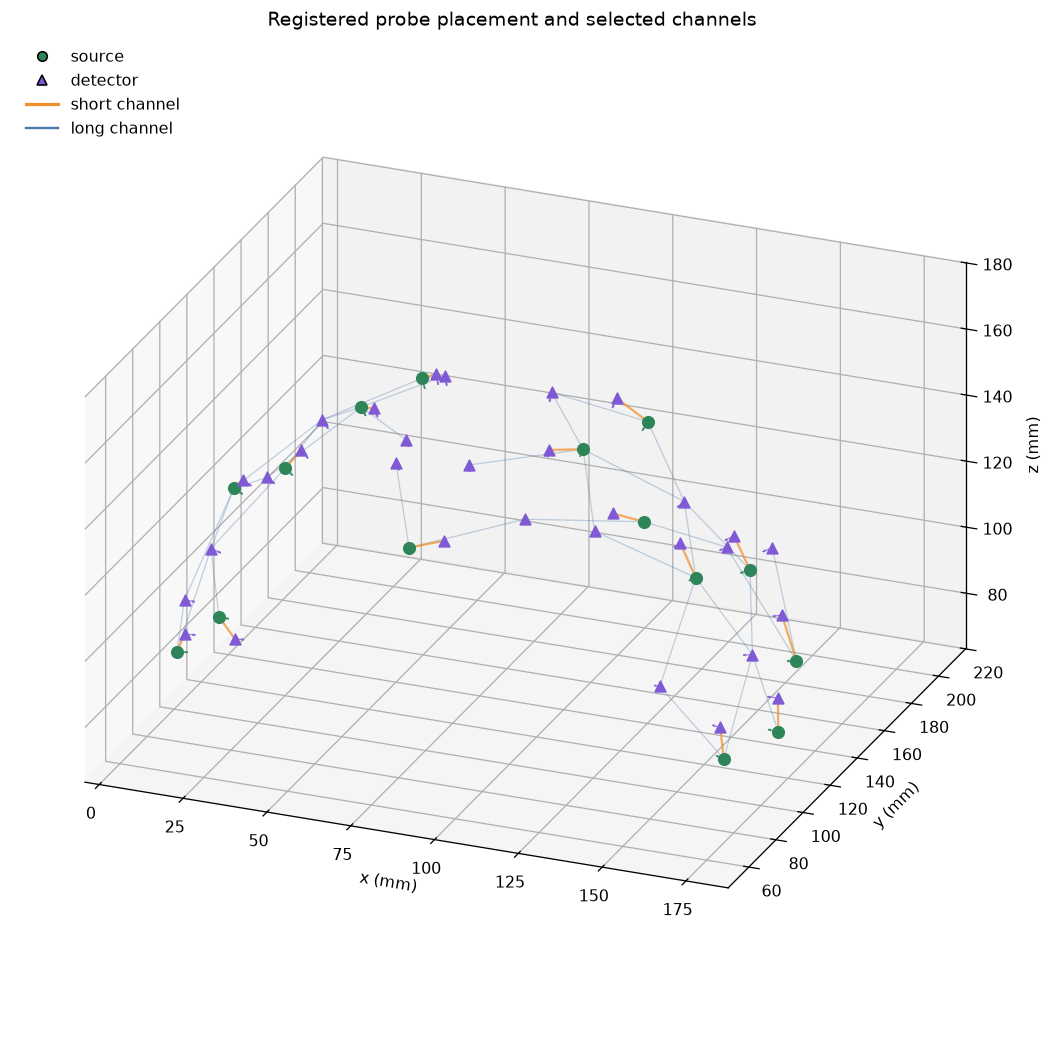

In [46]:
SHORT_COLOR = "#f28e2b"
LONG_COLOR = "#4c78a8"
SOURCE_COLOR = "#2f855a"
DETECTOR_COLOR = "#805ad5"

fig = plt.figure(figsize=(12, 9), layout="constrained")
ax = fig.add_subplot(111, projection="3d")

for channel_index, (source_index, detector_index) in enumerate(pairings):
    channel = np.vstack(
        (source_positions[source_index], detector_positions[detector_index])
    )
    ax.plot(
        *channel.T,
        color=SHORT_COLOR if channel_is_short[channel_index] else LONG_COLOR,
        linewidth=1.4 if channel_is_short[channel_index] else 0.8,
        alpha=0.72 if channel_is_short[channel_index] else 0.32,
    )

ax.scatter(
    *source_positions.T,
    s=52,
    color=SOURCE_COLOR,
    marker="o",
    depthshade=False,
)
ax.scatter(
    *detector_positions.T,
    s=45,
    color=DETECTOR_COLOR,
    marker="^",
    depthshade=False,
)
ax.quiver(
    *source_positions.T,
    *source_directions.T,
    length=DIRECTION_ARROW_LENGTH_MM,
    normalize=True,
    color=SOURCE_COLOR,
    linewidth=0.8,
    alpha=0.75,
)
ax.quiver(
    *detector_positions.T,
    *detector_directions.T,
    length=DIRECTION_ARROW_LENGTH_MM,
    normalize=True,
    color=DETECTOR_COLOR,
    linewidth=0.8,
    alpha=0.75,
)

coordinate_span = np.ptp(all_positions, axis=0)
ax.set_box_aspect(np.where(coordinate_span > 0, coordinate_span, 1.0))
ax.set_proj_type("ortho")
ax.view_init(elev=24, azim=-68)
ax.set(
    title="Registered probe placement and selected channels",
    xlabel="x (mm)",
    ylabel="y (mm)",
    zlabel="z (mm)",
)
ax.legend(
    handles=[
        Line2D([0], [0], marker="o", color="none", markerfacecolor=SOURCE_COLOR, label="source"),
        Line2D([0], [0], marker="^", color="none", markerfacecolor=DETECTOR_COLOR, label="detector"),
        Line2D([0], [0], color=SHORT_COLOR, linewidth=2, label="short channel"),
        Line2D([0], [0], color=LONG_COLOR, linewidth=1.5, label="long channel"),
    ],
    frameon=False,
    loc="upper left",
)
plt.show()

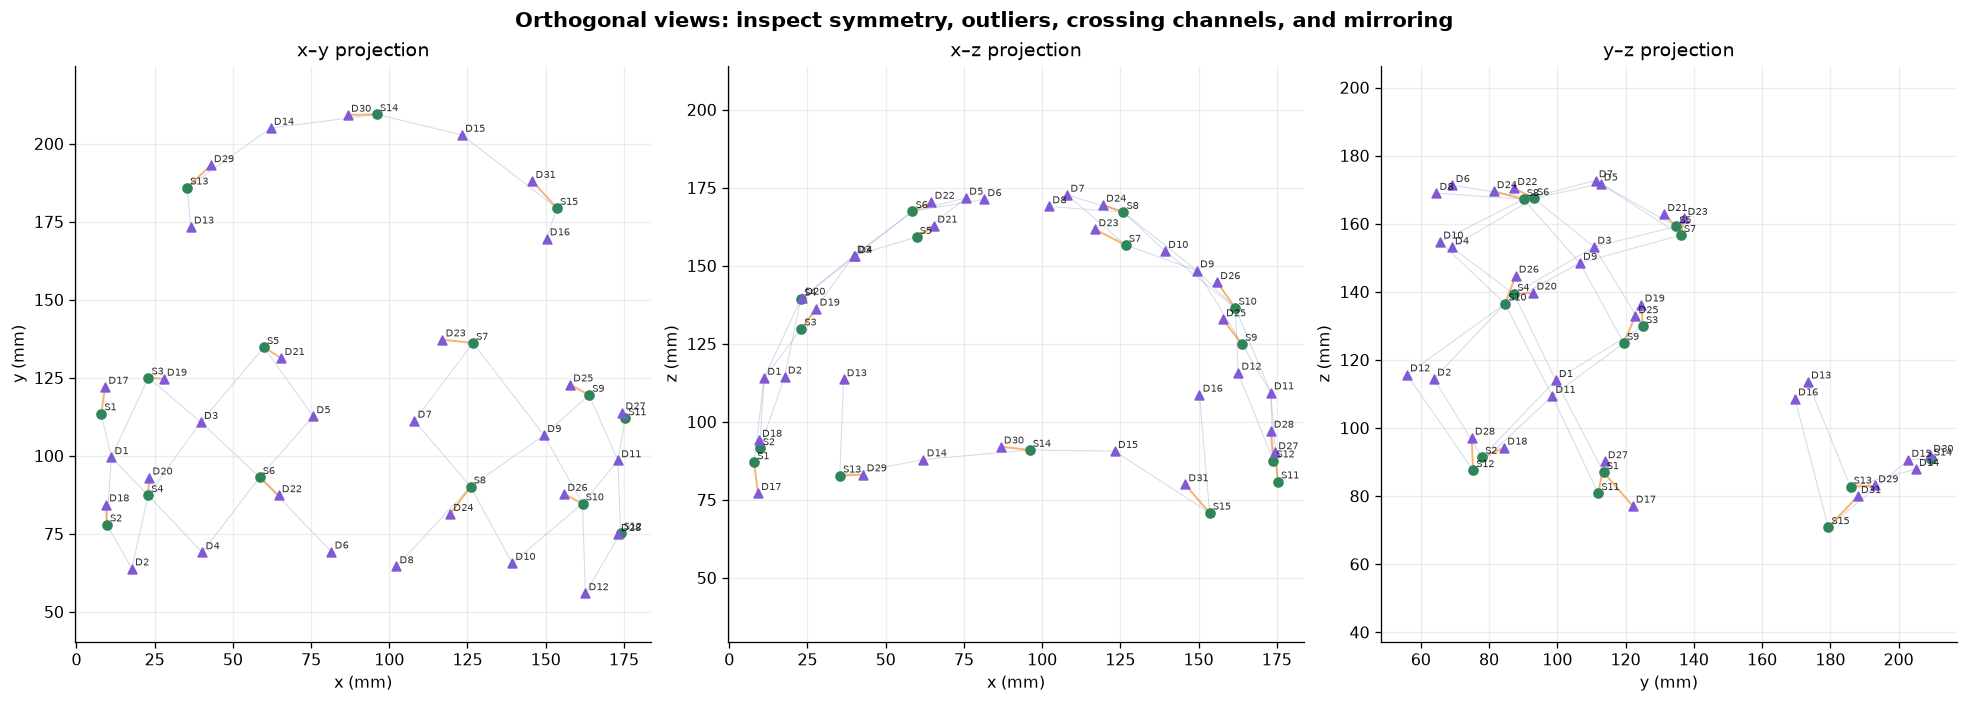

In [47]:
projection_specs = [
    (0, 1, "x", "y"),
    (0, 2, "x", "z"),
    (1, 2, "y", "z"),
]
fig, axes = plt.subplots(1, 3, figsize=(17, 6), layout="constrained")

for ax, (first, second, first_name, second_name) in zip(axes, projection_specs):
    for channel_index, (source_index, detector_index) in enumerate(pairings):
        channel = np.vstack(
            (source_positions[source_index], detector_positions[detector_index])
        )
        ax.plot(
            channel[:, first],
            channel[:, second],
            color=SHORT_COLOR if channel_is_short[channel_index] else LONG_COLOR,
            linewidth=1.25 if channel_is_short[channel_index] else 0.65,
            alpha=0.65 if channel_is_short[channel_index] else 0.25,
            zorder=1,
        )
    ax.scatter(
        source_positions[:, first],
        source_positions[:, second],
        s=32,
        color=SOURCE_COLOR,
        marker="o",
        zorder=3,
    )
    ax.scatter(
        detector_positions[:, first],
        detector_positions[:, second],
        s=30,
        color=DETECTOR_COLOR,
        marker="^",
        zorder=3,
    )
    if LABEL_2D_OPTODES:
        for label, coordinates in zip(optode_labels, all_positions):
            ax.annotate(
                label,
                (coordinates[first], coordinates[second]),
                xytext=(2, 2),
                textcoords="offset points",
                fontsize=6,
                alpha=0.8,
            )
    ax.set(
        title=f"{first_name}–{second_name} projection",
        xlabel=f"{first_name} (mm)",
        ylabel=f"{second_name} (mm)",
    )
    ax.set_aspect("equal", adjustable="datalim")

fig.suptitle(
    "Orthogonal views: inspect symmetry, outliers, crossing channels, and mirroring",
    fontsize=13,
    fontweight="bold",
)
plt.show()

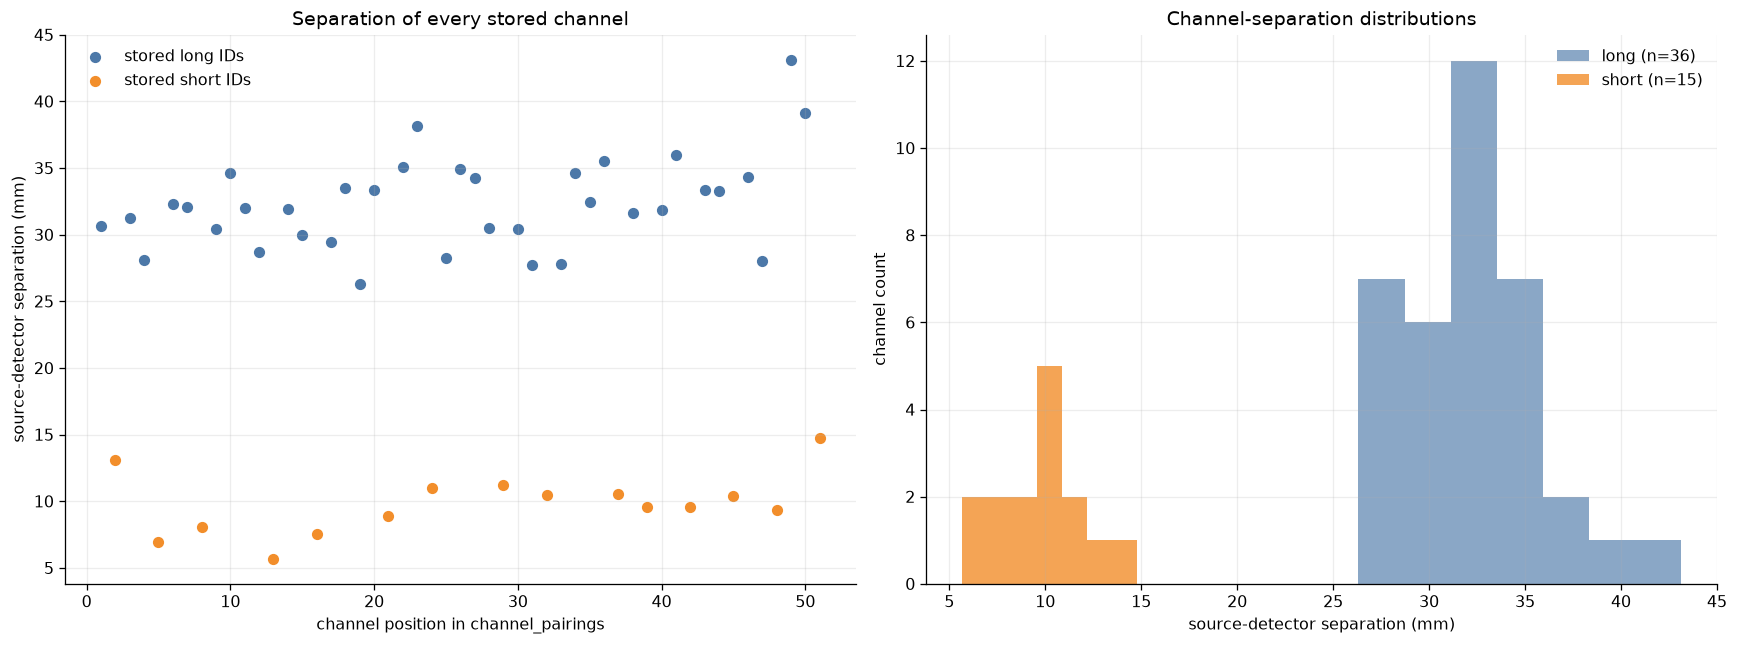

Short: min=5.680, median=9.583, max=14.785 mm
Long:  min=26.323, median=32.052, max=43.130 mm


In [48]:
short_distances = channel_distances[channel_is_short]
long_distances = channel_distances[channel_is_long]
channel_numbers = np.arange(1, len(pairings) + 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), layout="constrained")
axes[0].scatter(
    channel_numbers[channel_is_long],
    long_distances,
    color=LONG_COLOR,
    label="stored long IDs",
)
axes[0].scatter(
    channel_numbers[channel_is_short],
    short_distances,
    color=SHORT_COLOR,
    label="stored short IDs",
)
axes[0].set(
    title="Separation of every stored channel",
    xlabel="channel position in channel_pairings",
    ylabel="source-detector separation (mm)",
)
axes[0].legend(frameon=False)

bin_count = min(20, max(5, int(np.sqrt(len(pairings)))))
axes[1].hist(
    long_distances,
    bins=bin_count,
    color=LONG_COLOR,
    alpha=0.65,
    label=f"long (n={len(long_distances)})",
)
axes[1].hist(
    short_distances,
    bins=bin_count,
    color=SHORT_COLOR,
    alpha=0.8,
    label=f"short (n={len(short_distances)})",
)
axes[1].set(
    title="Channel-separation distributions",
    xlabel="source-detector separation (mm)",
    ylabel="channel count",
)
axes[1].legend(frameon=False)
plt.show()

def describe(values: np.ndarray) -> str:
    return (
        f"min={values.min():.3f}, median={np.median(values):.3f}, "
        f"max={values.max():.3f} mm"
    )

print(f"Short: {describe(short_distances)}")
print(f"Long:  {describe(long_distances)}")

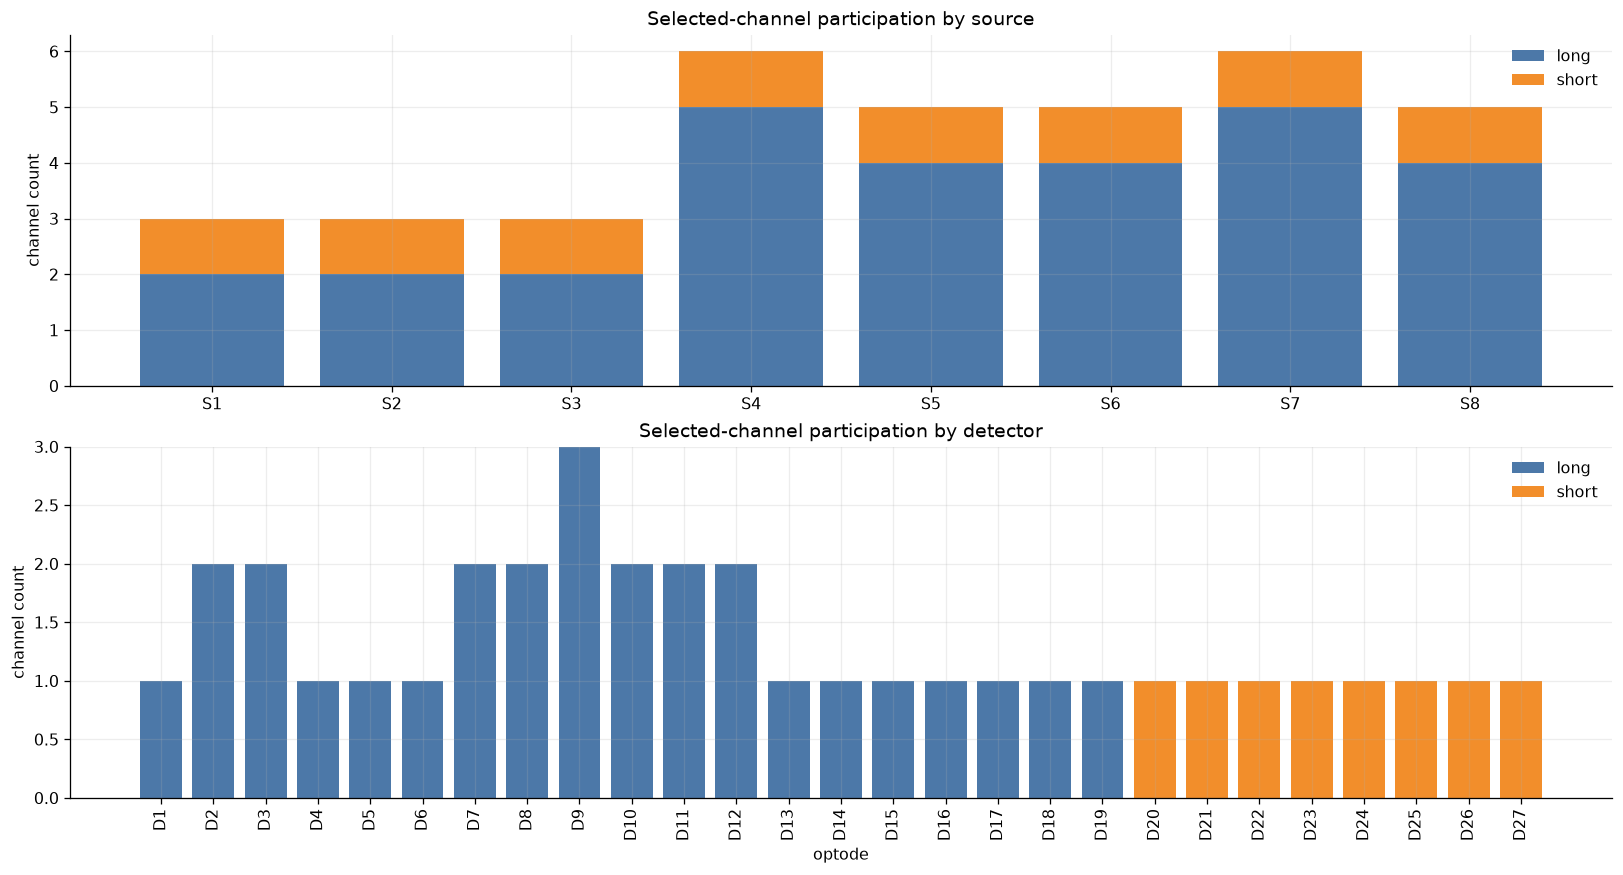

In [36]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7.5), layout="constrained")

source_x = np.arange(source_count)
axes[0].bar(source_x, source_long_count, color=LONG_COLOR, label="long")
axes[0].bar(
    source_x,
    source_short_count,
    bottom=source_long_count,
    color=SHORT_COLOR,
    label="short",
)
axes[0].set(
    title="Selected-channel participation by source",
    ylabel="channel count",
    xticks=source_x,
    xticklabels=[f"S{i + 1}" for i in range(source_count)],
)
axes[0].legend(frameon=False)

detector_x = np.arange(detector_count)
axes[1].bar(detector_x, detector_long_count, color=LONG_COLOR, label="long")
axes[1].bar(
    detector_x,
    detector_short_count,
    bottom=detector_long_count,
    color=SHORT_COLOR,
    label="short",
)
axes[1].set(
    title="Selected-channel participation by detector",
    xlabel="optode",
    ylabel="channel count",
    xticks=detector_x,
    xticklabels=[f"D{i + 1}" for i in range(detector_count)],
)
axes[1].tick_params(axis="x", rotation=90)
axes[1].legend(frameon=False)
plt.show()

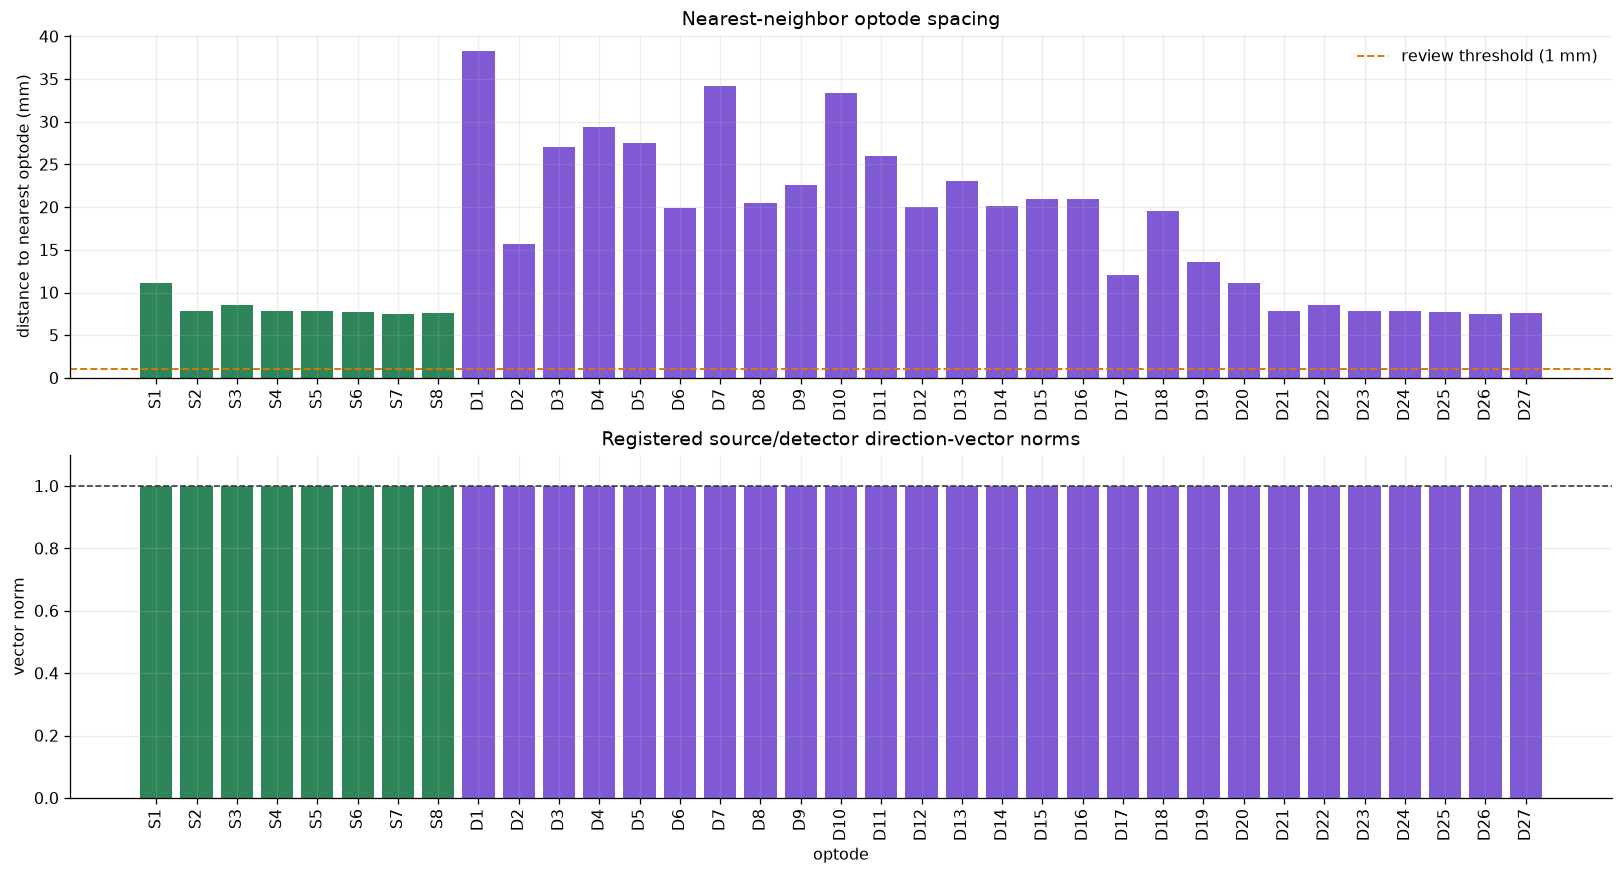

### Ten closest optode placements

| Optode | Nearest optode | Distance (mm) |
|:--|:--|--:|
| S7 | D26 | 7.456 |
| D26 | S7 | 7.456 |
| D27 | S8 | 7.609 |
| S8 | D27 | 7.609 |
| S6 | D25 | 7.691 |
| D25 | S6 | 7.691 |
| S5 | D24 | 7.801 |
| D24 | S5 | 7.801 |
| S4 | D23 | 7.866 |
| D23 | S4 | 7.866 |

In [37]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7.5), layout="constrained")
optode_index = np.arange(len(all_positions))
optode_colors = [SOURCE_COLOR] * source_count + [DETECTOR_COLOR] * detector_count

spacing_colors = np.where(
    nearest_neighbor_distance < MIN_OPTODE_SPACING_REVIEW_MM,
    "#d62728",
    optode_colors,
)
axes[0].bar(optode_index, nearest_neighbor_distance, color=spacing_colors)
axes[0].axhline(
    MIN_OPTODE_SPACING_REVIEW_MM,
    color="#d97706",
    linestyle="--",
    linewidth=1.2,
    label=f"review threshold ({MIN_OPTODE_SPACING_REVIEW_MM:g} mm)",
)
axes[0].set(
    title="Nearest-neighbor optode spacing",
    ylabel="distance to nearest optode (mm)",
    xticks=optode_index,
    xticklabels=optode_labels,
)
axes[0].tick_params(axis="x", rotation=90)
axes[0].legend(frameon=False)

direction_colors = np.where(bad_direction_norms, "#d62728", optode_colors)
axes[1].bar(optode_index, direction_norms, color=direction_colors)
axes[1].axhline(1.0, color="#333333", linestyle="--", linewidth=1)
axes[1].set_ylim(
    min(0.0, direction_norms.min(initial=1.0) - 0.05),
    max(1.1, direction_norms.max(initial=1.0) + 0.05),
)
axes[1].set(
    title="Registered source/detector direction-vector norms",
    xlabel="optode",
    ylabel="vector norm",
    xticks=optode_index,
    xticklabels=optode_labels,
)
axes[1].tick_params(axis="x", rotation=90)
plt.show()

nearest_lines = ["| Optode | Nearest optode | Distance (mm) |", "|:--|:--|--:|"]
for optode_index_value in np.argsort(nearest_neighbor_distance)[:10]:
    nearest_lines.append(
        f"| {optode_labels[optode_index_value]} | "
        f"{optode_labels[nearest_neighbor_index[optode_index_value]]} | "
        f"{nearest_neighbor_distance[optode_index_value]:.3f} |"
    )
display(Markdown("### Ten closest optode placements\n\n" + "\n".join(nearest_lines)))

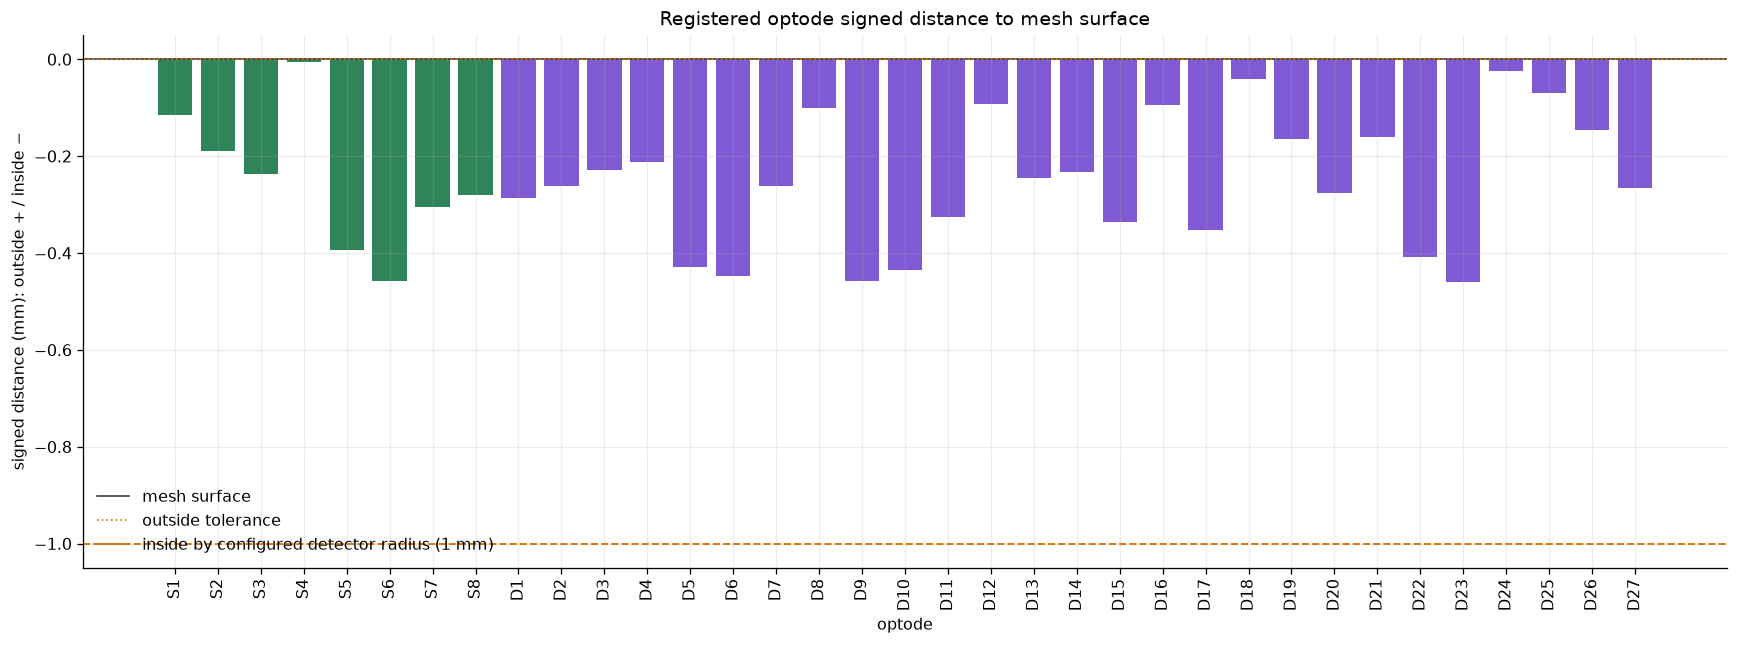

In [38]:
if surface_distances is None:
    display(
        Markdown(
            "## Mesh-relative placement\n\n"
            "Skipped. Set `MESH_PATH` to a compatible registered mesh to add "
            "inside/outside and surface-depth diagnostics."
        )
    )
else:
    deep_detector = detector_beyond_capture_radius
    bar_colors = [SOURCE_COLOR] * source_count + [
        "#d62728" if is_deep else DETECTOR_COLOR
        for is_deep in deep_detector
    ]
    optode_index = np.arange(len(all_positions))

    fig, ax = plt.subplots(figsize=(15, 5.5), layout="constrained")
    ax.bar(optode_index, surface_distances, color=bar_colors)
    ax.axhline(0.0, color="#333333", linewidth=1, label="mesh surface")
    ax.axhline(
        MESH_SURFACE_ATOL_MM,
        color="#d97706",
        linestyle=":",
        linewidth=1.1,
        label="outside tolerance",
    )
    if EXPECTED_DETECTOR_CAPTURE_RADIUS_MM is not None:
        ax.axhline(
            -float(EXPECTED_DETECTOR_CAPTURE_RADIUS_MM),
            color="#d97706",
            linestyle="--",
            linewidth=1.2,
            label=(
                "inside by configured detector radius "
                f"({EXPECTED_DETECTOR_CAPTURE_RADIUS_MM:g} mm)"
            ),
        )
    ax.set(
        title="Registered optode signed distance to mesh surface",
        xlabel="optode",
        ylabel="signed distance (mm): outside + / inside −",
        xticks=optode_index,
        xticklabels=optode_labels,
    )
    ax.tick_params(axis="x", rotation=90)
    ax.legend(frameon=False)
    plt.show()

    if np.any(deep_detector):
        deep_labels = [
            f"D{index + 1} ({detector_depth[index]:.3f} mm)"
            for index in np.flatnonzero(deep_detector)
        ]
        display(
            Markdown(
                "### Detectors deeper than the configured capture radius\n\n"
                + ", ".join(deep_labels)
            )
        )

## What to look for

- In the 3D and orthogonal views, investigate isolated clusters, flipped axes, large crossings, compressed coordinates, or direction arrows that point inconsistently.
- Separation plots should agree with the montage design. Stored short/long IDs are treated as authoritative; the notebook does not silently replace them with a generic distance cutoff.
- Participation bars expose unused optodes and unexpected hubs. Nearest-neighbor plots expose duplicates, unit errors, and registration collapse.
- Direction-vector norms test normalization only. Whether a direction points inward or outward requires mesh geometry.
- With a mesh, positive signed distance means an optode remains outside. Detector centers deeper than the capture radius deserve review before MMC because the detector sphere may not intersect photons leaving the surface.

For an eventual mmcnirs version, these checks should be close to `prepare_probe`: validate the saved archive, expose signed surface distance as a public utility, and record the forward-model detector radius in explicit metadata rather than relying on a later Jacobian convention.